# Notebook 2 — ML Model Building, Validation, Comparison & Explainability

**Objective:** Build, validate, compare, track, version, explain, and export the selected insurance-claim model using the modeling feature set produced by Notebook 1.

### Reproducibility and leakage controls
- The row split is exactly `train_test_split(stratify=y, random_state=42, test_size=0.20)`.
- The Logistic Regression and Decision Tree pipelines each receive a **fresh** `ColumnTransformer`; each preprocessor is fitted on its own `X_train` only.
- Cross-validation is stratified and performed only on training data.
- Test metrics are calculated only once on the held-out test set.
- The Decision Tree uses a rebuilt identical row split and a fresh preprocessor.
- All artifact paths are centralized under `OUT_DIR`.
- Verification cells assert the required outputs and metadata fields.

> **Prerequisite:** Run Notebook 1 first so that `cleaned_dataset.csv` exists, or place that file in the same working directory as this notebook.

In [30]:
# CELL 1 — Environment, configuration, dependency gate
from pathlib import Path
import json
import os
import re
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import optuna
import shap
import joblib
import statsmodels.api as sm

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET_COLUMN = "is_claim"
ID_COLUMN = "policy_id"
OUT_DIR = Path("/mnt/data/notebook2_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Required external packages for this notebook.
try:
    import mlflow
    import mlflow.sklearn
except ImportError as exc:
    raise ImportError(
        "MLflow is required for the requested experiment-tracking steps. "
        "Install mlflow in the notebook environment, then rerun this cell."
    ) from exc

try:
    import evidently
except ImportError as exc:
    raise ImportError(
        "Evidently is required for the requested train-vs-test quality/drift report. "
        "Install evidently in the notebook environment, then rerun this cell."
    ) from exc

print("Configuration ready.")
print("OUT_DIR:", OUT_DIR)
print("Random state:", RANDOM_STATE)
print("MLflow:", mlflow.__version__)
print("Evidently:", getattr(evidently, "__version__", "unknown"))

Configuration ready.
OUT_DIR: \mnt\data\notebook2_outputs
Random state: 42
MLflow: 3.15.1
Evidently: 0.7.21


In [31]:
# CELL 2 — Robust cleaned-dataset discovery, schema validation, and VIF feature recovery

def find_cleaned_dataset():
    candidates = [
        Path("/mnt/data/cleaned_dataset.csv"),
        Path.cwd() / "cleaned_dataset.csv",
        Path.cwd().parent / "cleaned_dataset.csv",
        Path("data/cleaned_dataset.csv"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "cleaned_dataset.csv was not found. Run Notebook 1 first or place the exported "
        "cleaned_dataset.csv in /mnt/data."
    )

DATA_PATH = find_cleaned_dataset()
df = pd.read_csv(DATA_PATH)

required_base = {ID_COLUMN, TARGET_COLUMN}
missing_required = required_base - set(df.columns)
assert not missing_required, f"Missing required columns: {sorted(missing_required)}"
assert df[ID_COLUMN].notna().all(), "policy_id contains missing values."
assert df[TARGET_COLUMN].isin([0, 1]).all(), "is_claim must be binary 0/1."

# Recover the Notebook-1 numeric modeling feature set reproducibly.
# Exclude ID, target, and all binary 0/1 flags.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
binary_numeric = {
    c for c in numeric_cols
    if set(df[c].dropna().unique()).issubset({0, 1})
}
vif_candidates = [
    c for c in numeric_cols
    if c not in {ID_COLUMN, TARGET_COLUMN}
    and c not in binary_numeric
    and df[c].nunique(dropna=True) > 1
]

# Remove one member of each highly correlated pair (> 0.90), deterministically
corr = df[vif_candidates].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr = {
    col for col in upper.columns
    if (upper[col] > 0.90).any()
}
vif_deduplicated = [c for c in vif_candidates if c not in drop_corr]

def calculate_vif(dataframe):
    values_df = dataframe.astype(float).copy()
    values_df = values_df.loc[:, values_df.nunique(dropna=True) > 1]
    values = values_df.to_numpy()
    rows = []
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    for idx, col in enumerate(values_df.columns):
        try:
            value = float(variance_inflation_factor(values, idx))
        except (ValueError, np.linalg.LinAlgError, FloatingPointError):
            value = np.inf
        rows.append({
            "feature": col,
            "VIF": value,
            "problematic_VIF_gt_10": bool(value > 10 or np.isinf(value))
        })
    return pd.DataFrame(rows).sort_values(
        "VIF", ascending=False, na_position="last"
    ).reset_index(drop=True)

vif_table = calculate_vif(df[vif_deduplicated])

# Keep strictly features with VIF <= 10 and non-infinite values
final_vif_table = vif_table.loc[
    (vif_table["VIF"] <= 10) & (~np.isinf(vif_table["VIF"]))
].reset_index(drop=True)

final_modeling_features = final_vif_table["feature"].tolist()

assert final_modeling_features, "No modeling features were recovered from Notebook 1 output."
assert set(final_modeling_features).issubset(df.columns)

print("Input:", DATA_PATH)
print("Dataset shape:", df.shape)
print("Final Modeling features (VIF <= 10):", final_modeling_features)
print("Features dropped due to VIF > 10 or inf:", vif_table.loc[vif_table.problematic_VIF_gt_10, "feature"].tolist())
display(final_vif_table)

Input: \mnt\data\cleaned_dataset.csv
Dataset shape: (58592, 91)
Final Modeling features (VIF <= 10): ['policy_tenure', 'age_of_car', 'population_density']
Features dropped due to VIF > 10 or inf: ['displacement', 'cylinder', 'turning_radius', 'height', 'gear_box', 'gross_weight', 'power_to_weight_ratio', 'airbags', 'ncap_rating', 'make', 'age_of_policyholder']


,feature,VIF,problematic_VIF_gt_10
0,policy_tenure,3.490606,False
1,age_of_car,3.317420,False
2,population_density,2.448439,False


In [32]:
# CELL 3 — Prepare X/y and create the exact 80/20 stratified split
X = df[final_modeling_features].copy()
y = df[TARGET_COLUMN].astype(int).copy()

assert len(X) == len(y)
assert y.nunique() == 2, "Target must contain exactly two classes."

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    random_state=42,
    test_size=0.20,
)

assert set(X_train.index).isdisjoint(set(X_test.index))
assert len(X_train) + len(X_test) == len(X)
assert y_train.value_counts().index.tolist() == y.value_counts().index.tolist()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print(f"Train claim rate: {y_train.mean():.4%}")
print(f"Test claim rate:  {y_test.mean():.4%}")
print(f"Overall claim rate:{y.mean():.4%}")

X_train shape: (46873, 3)
X_test shape: (11719, 3)
Train claim rate: 6.3960%
Test claim rate:  6.3999%
Overall claim rate:6.3968%


## Logistic Regression assumption checks

### Independence of observations
Independence cannot be mathematically proven from a flat tabular file alone. The code below performs a defensible structural check: duplicated policy identifiers and duplicate rows are treated as evidence that observations may not be independent. If `policy_id` is unique, the notebook records that no repeated policy identifier was detected and states the limitation explicitly.

### Linearity of the log-odds
Two checks are provided:
1. A decile/bin diagnostic for every continuous predictor, plotting empirical claim log-odds against the predictor-bin midpoint.
2. A formal Box–Tidwell-style interaction test using `x * log(x)` after a positive shift when necessary. The interaction p-value is reported for each continuous feature. Numerical/separation failures are captured rather than silently ignored.

In [33]:
# CELL 4 — Independence of observations check
duplicate_rows = int(df.duplicated().sum())
duplicate_ids = int(df[ID_COLUMN].duplicated(keep=False).sum())
unique_duplicate_ids = int(df.loc[df[ID_COLUMN].duplicated(keep=False), ID_COLUMN].nunique())

independence_check = pd.DataFrame([{
    "exact_duplicate_rows": duplicate_rows,
    "rows_with_repeated_policy_id": duplicate_ids,
    "repeated_policy_id_values": unique_duplicate_ids,
    "structural_independence_flag": (
        "PASS — no repeated policy_id detected; independence is not provable from tabular data alone."
        if duplicate_ids == 0 and duplicate_rows == 0
        else "REVIEW — repeated IDs and/or duplicate rows indicate possible dependence."
    )
}])
display(independence_check)

assert duplicate_rows == 0, (
    "Exact duplicate rows remain in the modeling dataset; inspect Notebook 1 before modeling."
)
assert duplicate_ids == 0, (
    "Repeated policy_id values detected. Independence of observations is questionable."
)

,exact_duplicate_rows,rows_with_repeated_policy_id,repeated_policy_id_values,structural_independence_flag
0,0,0,0,PASS — no repeated policy_id detected; indepen...


In [34]:
# CELL 5 — Build fresh ColumnTransformer for Logistic Regression (fit only on X_train)
def make_preprocessor(X_frame):
    numeric_features = X_frame.select_dtypes(include=np.number).columns.tolist()
    categorical_features = [
        c for c in X_frame.columns if c not in numeric_features
    ]
    transformers = [
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        )
    ]
    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )),
                ]),
                categorical_features,
            )
        )
    return ColumnTransformer(transformers=transformers, remainder="drop")

lr_preprocessor = make_preprocessor(X_train)
lr_preprocessor.fit(X_train)

# Explicit leakage guard: fitting on X_test must never occur.
assert hasattr(lr_preprocessor, "transformers_")
X_train_lr = lr_preprocessor.transform(X_train)
X_test_lr = lr_preprocessor.transform(X_test)
print("LR preprocessor fitted on X_train only.")
print("Transformed train/test shapes:", X_train_lr.shape, X_test_lr.shape)

LR preprocessor fitted on X_train only.
Transformed train/test shapes: (46873, 3) (11719, 3)


In [35]:
# Filter strictly continuous variables (at least 10 unique values) for deciles and Box-Tidwell
continuous_features = [
    col for col in X_train.select_dtypes(include=np.number).columns
    if X_train[col].nunique() >= 10
]

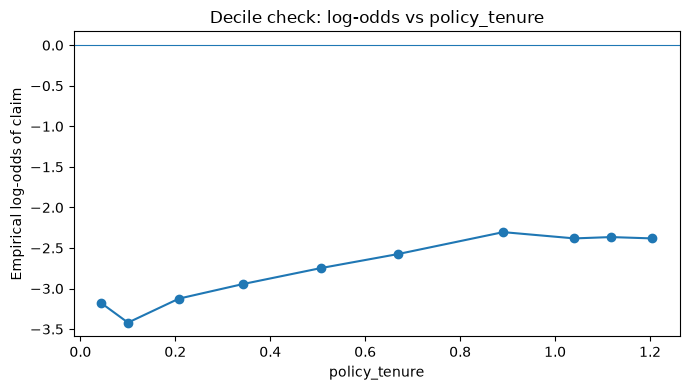

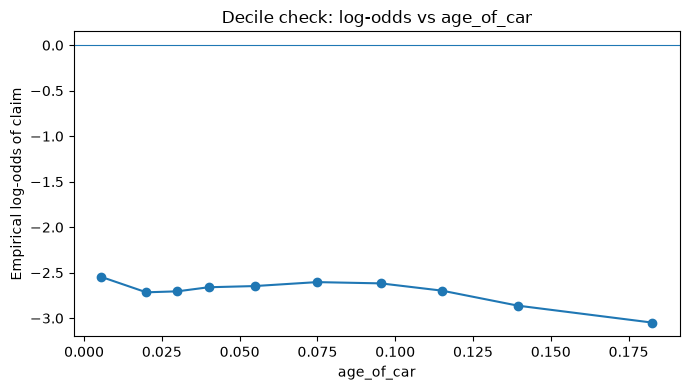

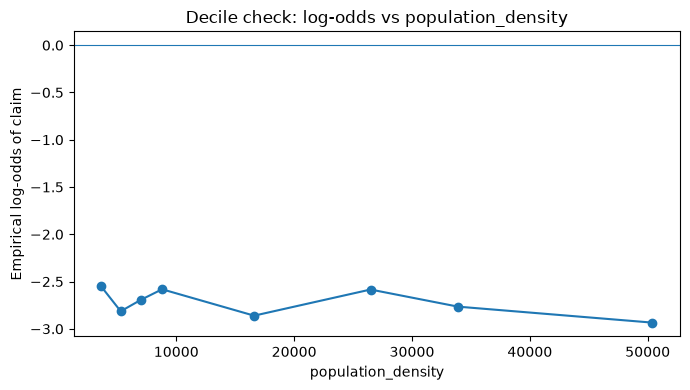

,feature,bins_used,log_odds_min,log_odds_max
0,policy_tenure,10,-3.419987,-2.304346
1,age_of_car,10,-3.048963,-2.546041
2,population_density,8,-2.934215,-2.551595


Visual interpretation: approximately straight/monotone patterns are more compatible with the logistic linearity assumption; strong curvature suggests review.


In [36]:
# CELL 6 — Decile visual linearity-of-log-odds check
def empirical_log_odds_table(x, y, bins=10):
    temp = pd.DataFrame({"x": x, "y": y}).dropna()
    if temp["x"].nunique() < 3:
        return None
    try:
        temp["bin"] = pd.qcut(temp["x"], q=bins, duplicates="drop")
    except ValueError:
        return None
    grouped = temp.groupby("bin", observed=True).agg(
        midpoint=("x", "mean"),
        n=("y", "size"),
        claims=("y", "sum"),
    ).reset_index()
    grouped["nonclaims"] = grouped["n"] - grouped["claims"]
    # Haldane-Anscombe correction avoids +/- infinity in empty claim/nonclaim bins.
    grouped["log_odds"] = np.log(
        (grouped["claims"] + 0.5) / (grouped["nonclaims"] + 0.5)
    )
    return grouped

continuous_features = X_train.select_dtypes(include=np.number).columns.tolist()
linearity_results = []

for feature in continuous_features:
    tbl = empirical_log_odds_table(X_train[feature], y_train, bins=10)
    if tbl is None:
        continue
    linearity_results.append({
        "feature": feature,
        "bins_used": len(tbl),
        "log_odds_min": tbl.log_odds.min(),
        "log_odds_max": tbl.log_odds.max(),
    })
    plt.figure(figsize=(7, 4))
    plt.plot(tbl["midpoint"], tbl["log_odds"], marker="o")
    plt.axhline(0, linewidth=0.8)
    plt.title(f"Decile check: log-odds vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("Empirical log-odds of claim")
    plt.tight_layout()
    plt.show()

linearity_results = pd.DataFrame(linearity_results)
display(linearity_results)
print("Visual interpretation: approximately straight/monotone patterns are more compatible with the logistic linearity assumption; strong curvature suggests review.")

In [46]:
# CELL 7 — Formal Box-Tidwell-style checks
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# Continuous features filter
continuous_features = [
    col for col in X_train.select_dtypes(include=np.number).columns
    if X_train[col].nunique() >= 10
]

def box_tidwell_single_feature(x, y):
    temp = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    
    if temp["x"].nunique() < 10 or temp["y"].nunique() < 2:
        return np.nan, "skipped_discrete_feature"
    
    raw = temp["x"].astype(float).to_numpy()
    
    # Scale x to a safe range [1, 10]
    x_min, x_max = raw.min(), raw.max()
    if x_max == x_min:
        return np.nan, "no_variance"
        
    x_pos = 1.0 + 9.0 * (raw - x_min) / (x_max - x_min)
    interaction = x_pos * np.log(x_pos)
    
    # Standardize
    x_std = (x_pos - x_pos.mean()) / (x_pos.std() or 1.0)
    inter_std = (interaction - interaction.mean()) / (interaction.std() or 1.0)
    
    # Model 1: Reduced model (Only Constant + X)
    X_reduced = sm.add_constant(x_std)
    
    # Model 2: Full model (Constant + X + X*log(X))
    X_full = sm.add_constant(np.column_stack([x_std, inter_std]))
    
    try:
        # Fit GLM (Binomial family) which is much more stable than sm.Logit
        model_reduced = sm.GLM(temp["y"].astype(float), X_reduced, family=sm.families.Binomial()).fit()
        model_full = sm.GLM(temp["y"].astype(float), X_full, family=sm.families.Binomial()).fit()
        
        # Likelihood Ratio Test (LRT) for the interaction term
        lr_stat = 2 * (model_full.llf - model_reduced.llf)
        pval = stats.chi2.sf(max(0, lr_stat), df=1)
        
        return float(pval), "ok"
    except Exception as exc:
        return np.nan, f"fit_failed: {type(exc).__name__}"

bt_rows = []
for feature in continuous_features:
    pval, status = box_tidwell_single_feature(X_train[feature], y_train)
    
    if status == "ok":
        flag = "compatible_at_0.05" if pval >= 0.05 else "possible_nonlinearity"
    else:
        flag = "skipped_or_unresolved"

    bt_rows.append({
        "feature": feature,
        "box_tidwell_interaction_p_value": pval,
        "status": status,
        "linearity_flag": flag
    })

box_tidwell_results = pd.DataFrame(bt_rows)
display(box_tidwell_results)
print("Formal check complete. Continuous features evaluated via Box-Tidwell.")

,feature,box_tidwell_interaction_p_value,status,linearity_flag
0,policy_tenure,0.000006,ok,possible_nonlinearity
1,age_of_car,0.776956,ok,compatible_at_0.05
2,population_density,0.005029,ok,possible_nonlinearity


Formal check complete. Continuous features evaluated via Box-Tidwell.


In [47]:
# CELL 8 — Baseline Logistic Regression
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

lr_pipeline = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("model", lr_model),
])

lr_pipeline.fit(X_train, y_train)
print("Baseline Logistic Regression fitted.")
print("class_weight='balanced'; max_iter=1000")

Baseline Logistic Regression fitted.
class_weight='balanced'; max_iter=1000


Logistic Regression — held-out test metrics
ACCURACY  : 0.561225
PRECISION : 0.080275
RECALL    : 0.560000
F1        : 0.140421
ROC_AUC   : 0.589146


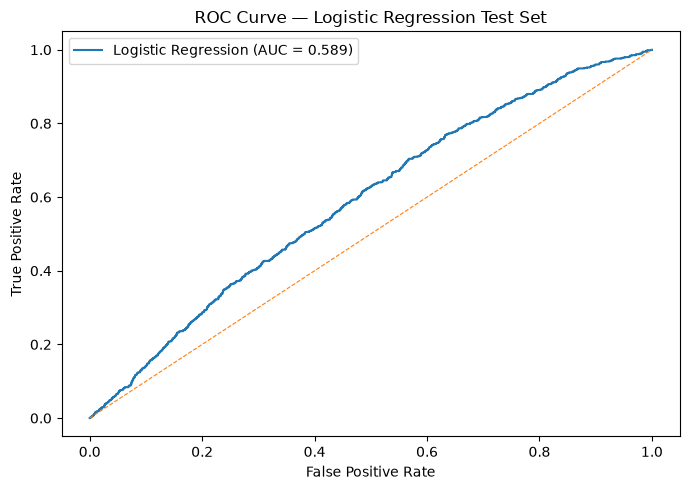

ROC saved: \mnt\data\notebook2_outputs\logistic_regression_roc_curve.png


In [48]:
# CELL 9 — Logistic Regression test metrics and ROC curve
def classification_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

lr_test_pred = lr_pipeline.predict(X_test)
lr_test_prob = lr_pipeline.predict_proba(X_test)[:, 1]
lr_test_metrics = classification_metrics(y_test, lr_test_pred, lr_test_prob)

print("Logistic Regression — held-out test metrics")
for key, value in lr_test_metrics.items():
    print(f"{key.upper():<10}: {value:.6f}")

fpr, tpr, _ = roc_curve(y_test, lr_test_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {lr_test_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression Test Set")
plt.legend()
plt.tight_layout()
roc_path = OUT_DIR / "logistic_regression_roc_curve.png"
plt.savefig(roc_path, dpi=160, bbox_inches="tight")
plt.show()
print("ROC saved:", roc_path)

In [49]:
# CELL 10 — 5-fold stratified CV for Logistic Regression + coefficient/odds-ratio table
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_validate(
    lr_pipeline, X_train, y_train,
    cv=cv5,
    scoring={"roc_auc": "roc_auc", "f1": "f1"},
    n_jobs=-1,
)
lr_cv_summary = {
    "cv_roc_auc_mean": lr_cv["test_roc_auc"].mean(),
    "cv_roc_auc_std": lr_cv["test_roc_auc"].std(ddof=1),
    "cv_f1_mean": lr_cv["test_f1"].mean(),
    "cv_f1_std": lr_cv["test_f1"].std(ddof=1),
}
print("Logistic Regression 5-fold stratified CV")
for k, v in lr_cv_summary.items():
    print(f"{k}: {v:.6f}")

fitted_pre = lr_pipeline.named_steps["preprocessor"]
fitted_lr = lr_pipeline.named_steps["model"]

def get_feature_names(preprocessor):
    names = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder":
            continue
        if hasattr(transformer, "named_steps") and "onehot" in transformer.named_steps:
            ohe = transformer.named_steps["onehot"]
            names.extend(ohe.get_feature_names_out(cols).tolist())
        else:
            names.extend(list(cols))
    return names

feature_names_lr = get_feature_names(fitted_pre)
coef = fitted_lr.coef_.ravel()
assert len(feature_names_lr) == len(coef)

coef_table = pd.DataFrame({
    "feature": feature_names_lr,
    "coefficient": coef,
})
coef_table["odds_ratio"] = np.exp(coef_table["coefficient"])
coef_table["direction"] = np.where(
    coef_table["coefficient"] > 0, "positive",
    np.where(coef_table["coefficient"] < 0, "negative", "neutral")
)
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values(
    "abs_coefficient", ascending=False
).drop(columns="abs_coefficient").reset_index(drop=True)
display(coef_table.head(30))
coef_table.to_csv(OUT_DIR / "logistic_coefficients_odds_ratios.csv", index=False)

Logistic Regression 5-fold stratified CV
cv_roc_auc_mean: 0.608888
cv_roc_auc_std: 0.007224
cv_f1_mean: 0.147159
cv_f1_std: 0.002024


,feature,coefficient,odds_ratio,direction
0,policy_tenure,0.385810,1.470806,positive
1,age_of_car,-0.195962,0.822043,negative
2,population_density,-0.060724,0.941083,negative


## Decision Tree model: identical row split, fresh preprocessor, Optuna tuning

The second model intentionally reconstructs the split from the same `X`/`y` using the exact same parameters. The resulting indices are asserted to match the Logistic Regression split. A completely new `ColumnTransformer` is created and fitted only through the Decision Tree pipeline/CV process.

In [50]:
# CELL 11 — Rebuild identical row split and fresh Decision Tree preprocessor
X2 = df[final_modeling_features].copy()
y2 = df[TARGET_COLUMN].astype(int).copy()

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2,
    stratify=y2,
    random_state=42,
    test_size=0.20,
)

assert X_train2.index.equals(X_train.index), "X_train2 and X_train indices differ."
assert X_test2.index.equals(X_test.index), "X_test2 and X_test indices differ."
assert y_train2.index.equals(y_train.index)
assert y_test2.index.equals(y_test.index)

tree_preprocessor = make_preprocessor(X_train2)
# Explicit fit on X_train2 only; this object is not reused from Logistic Regression.
tree_preprocessor.fit(X_train2)
print("Fresh Decision Tree preprocessor created and fitted on X_train2 only.")
print("It is distinct from LR preprocessor:", tree_preprocessor is not lr_preprocessor)

Fresh Decision Tree preprocessor created and fitted on X_train2 only.
It is distinct from LR preprocessor: True


In [51]:
# CELL 12 — Optuna 25-trial / 3-fold CV ROC-AUC tuning
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def tree_objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
    }
    model = DecisionTreeClassifier(
        **params,
        class_weight="balanced",
        random_state=42,
    )
    pipe = Pipeline([
        ("preprocessor", make_preprocessor(X_train2)),
        ("model", model),
    ])
    scores = cross_validate(
        pipe, X_train2, y_train2,
        cv=cv3,
        scoring="roc_auc",
        n_jobs=-1,
    )
    return float(scores["test_score"].mean())

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(tree_objective, n_trials=25)

print("Best trial value (3-fold CV ROC-AUC):", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

assert len(study.trials) == 25
assert 3 <= study.best_params["max_depth"] <= 15
assert 2 <= study.best_params["min_samples_split"] <= 50
assert 1 <= study.best_params["min_samples_leaf"] <= 30

[I 2026-08-12 12:35:18,221] A new study created in memory with name: no-name-e9d93a0a-078f-41e3-a28a-550feba8c7cf
[I 2026-08-12 12:35:18,753] Trial 0 finished with value: 0.6151849932553636 and parameters: {'max_depth': 7, 'min_samples_split': 48, 'min_samples_leaf': 22}. Best is trial 0 with value: 0.6151849932553636.
[I 2026-08-12 12:35:19,228] Trial 1 finished with value: 0.5917483925406889 and parameters: {'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.6151849932553636.
[I 2026-08-12 12:35:19,658] Trial 2 finished with value: 0.6230571747816193 and parameters: {'max_depth': 3, 'min_samples_split': 44, 'min_samples_leaf': 19}. Best is trial 2 with value: 0.6230571747816193.
[I 2026-08-12 12:35:20,128] Trial 3 finished with value: 0.5763837810345959 and parameters: {'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 30}. Best is trial 2 with value: 0.6230571747816193.
[I 2026-08-12 12:35:20,552] Trial 4 finished with value: 0.

Best trial value (3-fold CV ROC-AUC): 0.6277677671745819
Best hyperparameters:
{'max_depth': 4, 'min_samples_split': 16, 'min_samples_leaf': 11}


In [52]:
# CELL 13 — Fit tuned Decision Tree pipeline and evaluate on test
best_tree = DecisionTreeClassifier(
    **study.best_params,
    class_weight="balanced",
    random_state=42,
)
tree_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", best_tree),
])
tree_pipeline.fit(X_train2, y_train2)

tree_test_pred = tree_pipeline.predict(X_test2)
tree_test_prob = tree_pipeline.predict_proba(X_test2)[:, 1]
tree_test_metrics = classification_metrics(y_test2, tree_test_pred, tree_test_prob)

print("Tuned Decision Tree — held-out test metrics")
for key, value in tree_test_metrics.items():
    print(f"{key.upper():<10}: {value:.6f}")

Tuned Decision Tree — held-out test metrics
ACCURACY  : 0.519072
PRECISION : 0.083816
RECALL    : 0.656000
F1        : 0.148640
ROC_AUC   : 0.630864


In [53]:
# CELL 14 — 5-fold CV for BOTH models + side-by-side comparison and selection
tree_cv = cross_validate(
    tree_pipeline, X_train2, y_train2,
    cv=cv5,
    scoring={"roc_auc": "roc_auc", "f1": "f1"},
    n_jobs=-1,
)
tree_cv_summary = {
    "cv_roc_auc_mean": tree_cv["test_roc_auc"].mean(),
    "cv_roc_auc_std": tree_cv["test_roc_auc"].std(ddof=1),
    "cv_f1_mean": tree_cv["test_f1"].mean(),
    "cv_f1_std": tree_cv["test_f1"].std(ddof=1),
}

comparison = pd.DataFrame([
    {
        "model": "LogisticRegression",
        **lr_test_metrics,
        **lr_cv_summary,
    },
    {
        "model": "DecisionTree",
        **tree_test_metrics,
        **tree_cv_summary,
    }
])
comparison = comparison[
    [
        "model", "accuracy", "precision", "recall", "f1", "roc_auc",
        "cv_roc_auc_mean", "cv_roc_auc_std", "cv_f1_mean", "cv_f1_std"
    ]
]
display(comparison)

selected_model_name = comparison.loc[
    comparison["roc_auc"].idxmax(), "model"
]
assert selected_model_name in {"LogisticRegression", "DecisionTree"}

if selected_model_name == "LogisticRegression":
    chosen_pipeline = lr_pipeline
    chosen_X_test = X_test
    chosen_y_test = y_test
    chosen_test_prob = lr_test_prob
    chosen_test_pred = lr_test_pred
    chosen_test_metrics = lr_test_metrics
    chosen_cv = lr_cv_summary
    chosen_params = {
        "class_weight": "balanced",
        "max_iter": 1000,
    }
else:
    chosen_pipeline = tree_pipeline
    chosen_X_test = X_test2
    chosen_y_test = y_test2
    chosen_test_prob = tree_test_prob
    chosen_test_pred = tree_test_pred
    chosen_test_metrics = tree_test_metrics
    chosen_cv = tree_cv_summary
    chosen_params = {
        **study.best_params,
        "class_weight": "balanced",
        "random_state": 42,
    }

print("Selected model:", selected_model_name)
print("Selection rule: higher held-out test ROC-AUC.")

,model,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean,cv_roc_auc_std,cv_f1_mean,cv_f1_std
0,LogisticRegression,0.561225,0.080275,0.560,0.140421,0.589146,0.608888,0.007224,0.147159,0.002024
1,DecisionTree,0.519072,0.083816,0.656,0.148640,0.630864,0.629094,0.011953,0.155565,0.004373


Selected model: DecisionTree
Selection rule: higher held-out test ROC-AUC.


## MLflow experiment tracking

Both models are logged as separate runs in the `SafeDrive_Claim_Prediction` experiment. Each run records model type/hyperparameters and the required test/CV metrics, and logs the fitted sklearn pipeline as a model artifact.

In [56]:
# CELL 15 — MLflow tracking for both models (Cloudpickle serialization fix)

mlflow_db = OUT_DIR / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_db}")
mlflow.set_experiment("SafeDrive_Claim_Prediction")

def log_pipeline_model(pipeline, artifact_name="model"):
    # Use cloudpickle serialization format to avoid skops untrusted types/CVE restrictions
    try:
        return mlflow.sklearn.log_model(
            pipeline, 
            name=artifact_name, 
            serialization_format="cloudpickle"
        )
    except TypeError:
        # Fallback for older MLflow API signatures using 'artifact_path'
        try:
            return mlflow.sklearn.log_model(
                pipeline, 
                artifact_path=artifact_name, 
                serialization_format="cloudpickle"
            )
        except TypeError:
            # Fallback passing trusted types list if serialization_format isn't accepted
            return mlflow.sklearn.log_model(
                pipeline, 
                artifact_path=artifact_name, 
                skops_trusted_types=["numpy.dtype"]
            )

lr_params = {"max_iter": 1000, "class_weight": "balanced"}
lr_tracking_metrics = {
    "roc_auc": lr_test_metrics["roc_auc"],
    "precision": lr_test_metrics["precision"],
    "recall": lr_test_metrics["recall"],
    "f1": lr_test_metrics["f1"],
    "cv_roc_auc_mean": lr_cv_summary["cv_roc_auc_mean"],
}

tree_params = {
    **study.best_params,
    "class_weight": "balanced",
    "random_state": 42,
}
tree_tracking_metrics = {
    "roc_auc": tree_test_metrics["roc_auc"],
    "precision": tree_test_metrics["precision"],
    "recall": tree_test_metrics["recall"],
    "f1": tree_test_metrics["f1"],
    "cv_roc_auc_mean": tree_cv_summary["cv_roc_auc_mean"],
}

def log_model_run(model_name, pipeline, params, metrics):
    with mlflow.start_run(run_name=model_name) as run:
        mlflow.log_param("model_type", model_name)
        for key, value in params.items():
            mlflow.log_param(key, value)
        for key, value in metrics.items():
            mlflow.log_metric(key, float(value))
        log_pipeline_model(pipeline, artifact_name="model")
        return run.info.run_id

lr_run_id = log_model_run(
    "LogisticRegression", lr_pipeline, lr_params, lr_tracking_metrics
)
tree_run_id = log_model_run(
    "DecisionTree", tree_pipeline, tree_params, tree_tracking_metrics
)

runs = mlflow.search_runs(
    experiment_names=["SafeDrive_Claim_Prediction"],
    output_format="pandas",
)
runs.to_csv(OUT_DIR / "experiment_comparison_log.csv", index=False)

assert lr_run_id and tree_run_id
assert len(runs) >= 2
print("LR run:", lr_run_id)
print("Tree run:", tree_run_id)
print("Experiment log:", OUT_DIR / "experiment_comparison_log.csv")
display(runs[["run_id", "status", "params.model_type", "metrics.roc_auc", "metrics.f1", "metrics.cv_roc_auc_mean"]].head())

2026/08/12 12:36:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/08/12 12:37:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LR run: f64b4993c5034d86b327a74a09d0b1d0
Tree run: ac9fed8e4e934f79826bdb01d42d17fa
Experiment log: \mnt\data\notebook2_outputs\experiment_comparison_log.csv


,run_id,status,params.model_type,metrics.roc_auc,metrics.f1,metrics.cv_roc_auc_mean
0,ac9fed8e4e934f79826bdb01d42d17fa,FINISHED,DecisionTree,0.630864,0.148640,0.629094
1,f64b4993c5034d86b327a74a09d0b1d0,FINISHED,LogisticRegression,0.589146,0.140421,0.608888
2,78ea9b489cec44a19ed3c014be987168,FAILED,LogisticRegression,0.589146,0.140421,0.608888
3,a28702e1591b4869913344fb7c4fa8cc,FAILED,LogisticRegression,0.589146,0.140421,0.608888
4,00f7f94ddbe54bb5841d858a734a4dac,FAILED,LogisticRegression,0.589146,0.140421,0.608888


In [57]:
# CELL 16 — Persist chosen model with v1_UTC timestamp + structured JSON metadata
timestamp_utc = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
model_version = f"v1_{timestamp_utc}"
model_path = OUT_DIR / f"{model_version}.joblib"
metadata_path = OUT_DIR / f"{model_version}_metadata.json"

joblib.dump(chosen_pipeline, model_path)

chosen_run_id = lr_run_id if selected_model_name == "LogisticRegression" else tree_run_id
metadata = {
    "model_name": selected_model_name,
    "model_version": model_version,
    "mlflow_run_id": chosen_run_id,
    "training_data_reference": str(DATA_PATH),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_columns": list(final_modeling_features),
    "metric_summary": {
        "accuracy": float(chosen_test_metrics["accuracy"]),
        "precision": float(chosen_test_metrics["precision"]),
        "recall": float(chosen_test_metrics["recall"]),
        "f1": float(chosen_test_metrics["f1"]),
        "roc_auc": float(chosen_test_metrics["roc_auc"]),
        "cv_roc_auc_mean": float(chosen_cv["cv_roc_auc_mean"]),
        "cv_roc_auc_std": float(chosen_cv["cv_roc_auc_std"]),
        "cv_f1_mean": float(chosen_cv["cv_f1_mean"]),
        "cv_f1_std": float(chosen_cv["cv_f1_std"]),
    },
    "approval_status": "PENDING_REVIEW",
    "created_at": datetime.now(timezone.utc).isoformat(),
}

required_metadata_fields = {
    "model_name", "model_version", "mlflow_run_id", "training_data_reference",
    "training_rows", "test_rows", "feature_columns", "metric_summary",
    "approval_status", "created_at"
}
assert set(metadata) == required_metadata_fields

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

assert model_path.exists() and model_path.stat().st_size > 0
assert metadata_path.exists()
print("Model:", model_path)
print("Metadata:", metadata_path)

Model: \mnt\data\notebook2_outputs\v1_20260812T070950Z.joblib
Metadata: \mnt\data\notebook2_outputs\v1_20260812T070950Z_metadata.json


## Evidently train-vs-test data quality and drift report

The notebook first tries the current Evidently `Report + DataSummaryPreset + DataDriftPreset` API. If that API is unavailable because of an older Evidently release, it falls back to the legacy metric-preset interface. The saved report must contain both **data summary/quality** and **data drift** information.

In [58]:
# CELL 17 — Evidently report with current API first, legacy fallback second
evidently_report_path = OUT_DIR / "evidently_train_vs_test_report.html"

try:
    from evidently import Report
    from evidently.presets import DataSummaryPreset, DataDriftPreset

    report = Report([
        DataSummaryPreset(),
        DataDriftPreset(),
    ])
    report = report.run(
        current_data=X_test.copy(),
        reference_data=X_train.copy(),
    )
    report.save_html(str(evidently_report_path))
    evidently_api_used = "current: Report + DataSummaryPreset + DataDriftPreset"

except Exception as current_exc:
    try:
        # Legacy fallback retained for environments with older Evidently versions.
        from evidently.report import Report
        from evidently.metric_preset import DataQualityPreset, DataDriftPreset as LegacyDataDriftPreset

        legacy_report = Report(metrics=[
            DataQualityPreset(),
            LegacyDataDriftPreset(),
        ])
        legacy_report.run(
            reference_data=X_train.copy(),
            current_data=X_test.copy(),
        )
        legacy_report.save(str(evidently_report_path))
        evidently_api_used = "legacy: Report + DataQualityPreset + DataDriftPreset"
    except Exception as legacy_exc:
        raise RuntimeError(
            "Both current and legacy Evidently APIs failed. "
            f"Current error: {type(current_exc).__name__}: {current_exc}; "
            f"Legacy error: {type(legacy_exc).__name__}: {legacy_exc}"
        )

assert evidently_report_path.exists() and evidently_report_path.stat().st_size > 0
print("Evidently API:", evidently_api_used)
print("Report:", evidently_report_path)

Evidently API: current: Report + DataSummaryPreset + DataDriftPreset
Report: \mnt\data\notebook2_outputs\evidently_train_vs_test_report.html


## SHAP explainability

The selected pipeline's fitted preprocessor is used to transform `X_test`—never a newly fitted transformer. Readable feature names are reconstructed as:

`numeric_features + ohe.get_feature_names_out(categorical_features)`

For a Decision Tree, `TreeExplainer` is used. For Logistic Regression, `KernelExplainer` uses a maximum 200-row background sample. The code handles both legacy list-of-arrays SHAP output and newer 3-D array output.

In [59]:
# CELL 18 — Transform X_test and rebuild readable names for SHAP
chosen_pre = chosen_pipeline.named_steps["preprocessor"]
chosen_estimator = chosen_pipeline.named_steps["model"]

X_test_transformed = chosen_pre.transform(chosen_X_test)

numeric_features_chosen = chosen_X_test.select_dtypes(include=np.number).columns.tolist()
categorical_features_chosen = [
    c for c in chosen_X_test.columns if c not in numeric_features_chosen
]

# Rebuild names from the fitted transformer, including one-hot expansion.
shap_feature_names = []
for name, transformer, cols in chosen_pre.transformers_:
    if name == "remainder":
        continue
    if hasattr(transformer, "named_steps") and "onehot" in transformer.named_steps:
        ohe = transformer.named_steps["onehot"]
        shap_feature_names.extend(ohe.get_feature_names_out(cols).tolist())
    else:
        shap_feature_names.extend(list(cols))

assert len(shap_feature_names) == X_test_transformed.shape[1]

X_test_shap = pd.DataFrame(
    np.asarray(X_test_transformed),
    columns=shap_feature_names,
    index=chosen_X_test.index,
)
display(X_test_shap.head())
print("SHAP input shape:", X_test_shap.shape)

,policy_tenure,age_of_car,population_density
38215,0.870025,-0.708879,1.107773
3597,-1.427307,-0.527514,2.665761
32004,-0.441446,-1.071610,-0.781893
20540,1.077009,-0.890244,-0.828234
55338,-1.276391,0.379312,1.107773


SHAP input shape: (11719, 3)


In [60]:
# CELL 19 — Compute SHAP values with model-specific explainer and normalize output
if selected_model_name == "DecisionTree":
    explainer = shap.TreeExplainer(chosen_estimator)
    raw_shap = explainer.shap_values(X_test_shap)
else:
    background_n = min(200, len(X_train))
    background = chosen_pipeline.named_steps["preprocessor"].transform(
        X_train.sample(background_n, random_state=42)
    )
    background = np.asarray(background)
    # Prediction function receives transformed arrays and returns positive-class probabilities.
    predict_positive = lambda arr: chosen_estimator.predict_proba(np.asarray(arr))[:, 1]
    explainer = shap.KernelExplainer(predict_positive, background)
    raw_shap = explainer.shap_values(
        X_test_shap.to_numpy(),
        nsamples="auto",
    )

def normalize_positive_class_shap(values):
    arr = np.asarray(values)
    if isinstance(values, list):
        if len(values) == 2:
            return np.asarray(values[1])
        return np.asarray(values[0])
    if arr.ndim == 3:
        # Common new format: observations x features x outputs.
        if arr.shape[-1] == 2:
            return arr[:, :, 1]
        # Alternate format: outputs x observations x features.
        if arr.shape[0] == 2:
            return arr[1, :, :]
        raise ValueError(f"Unsupported 3-D SHAP shape: {arr.shape}")
    if arr.ndim == 2:
        return arr
    raise ValueError(f"Unsupported SHAP output shape: {arr.shape}")

shap_values = normalize_positive_class_shap(raw_shap)
assert shap_values.shape == X_test_shap.shape
print("Normalized SHAP shape:", shap_values.shape)

Normalized SHAP shape: (11719, 3)


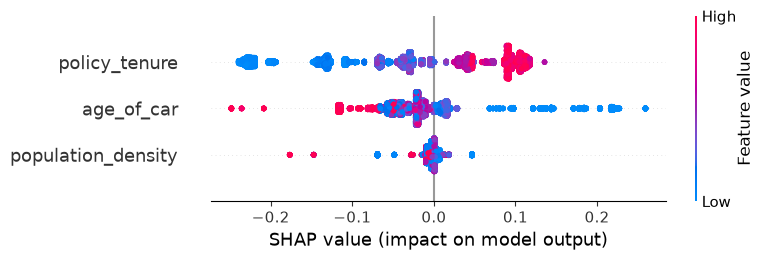

,feature,mean_abs_shap,mean_signed_shap,direction
0,policy_tenure,0.095398,-0.017599,negative
1,age_of_car,0.045237,-0.010637,negative
2,population_density,0.006606,-0.002773,negative


SHAP CSV: \mnt\data\notebook2_outputs\shap_feature_summary.csv
SHAP plot: \mnt\data\notebook2_outputs\shap_summary_plot.png


In [61]:
# CELL 20 — SHAP summary plot + feature-level summary CSV
shap_summary = pd.DataFrame({
    "feature": shap_feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "mean_signed_shap": shap_values.mean(axis=0),
})
shap_summary["direction"] = np.where(
    shap_summary["mean_signed_shap"] > 0, "positive",
    np.where(shap_summary["mean_signed_shap"] < 0, "negative", "neutral")
)
shap_summary = shap_summary.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)

shap_csv_path = OUT_DIR / "shap_feature_summary.csv"
shap_summary.to_csv(shap_csv_path, index=False)

shap_plot_path = OUT_DIR / "shap_summary_plot.png"
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig(shap_plot_path, dpi=180, bbox_inches="tight")
plt.show()

display(shap_summary.head(15))
assert shap_csv_path.exists() and shap_plot_path.exists()
print("SHAP CSV:", shap_csv_path)
print("SHAP plot:", shap_plot_path)

## Final prediction output and dynamic risk bands

Risk cut points are computed dynamically from the chosen model's predicted probabilities at the **40th, 75th, and 90th percentiles**. The bands are therefore adapted to the probability distribution produced by the class-weighted model rather than using arbitrary fixed thresholds.

In [62]:
# CELL 21 — Quantile-based risk levels, monotonicity sanity check, and export
prediction_output = pd.DataFrame({
    "policy_id": df.loc[chosen_X_test.index, ID_COLUMN].values,
    "actual_outcome": chosen_y_test.values,
    "predicted_class": chosen_test_pred.astype(int),
    "claim_probability": chosen_test_prob.astype(float),
})

q40, q75, q90 = np.quantile(
    prediction_output["claim_probability"],
    [0.40, 0.75, 0.90]
)

# Make cut points strictly ordered when ties occur, without changing the
# underlying quantile values conceptually. Tied probability masses are kept
# in the higher band only when necessary to preserve ordered bins.
if q40 >= q75 or q75 >= q90:
    unique_probs = np.sort(prediction_output["claim_probability"].unique())
    if len(unique_probs) >= 4:
        q40, q75, q90 = np.quantile(unique_probs, [0.40, 0.75, 0.90])

prediction_output["risk_level"] = pd.cut(
    prediction_output["claim_probability"],
    bins=[-np.inf, q40, q75, q90, np.inf],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True,
    duplicates="drop",
)

# If extreme probability ties collapse a boundary, fail loudly rather than
# silently claiming four distinct risk bands.
assert prediction_output["risk_level"].notna().all()

risk_order = ["Low", "Medium", "High", "Very High"]
risk_summary = (
    prediction_output.groupby("risk_level", observed=False)
    .agg(
        rows=("actual_outcome", "size"),
        actual_claim_rate=("actual_outcome", "mean"),
        mean_probability=("claim_probability", "mean"),
    )
    .reindex(risk_order)
)
display(risk_summary)

rates = risk_summary["actual_claim_rate"].dropna().to_numpy()
monotonic_increase = bool(np.all(np.diff(rates) >= 0))
strict_increase = bool(np.all(np.diff(rates) > 0))

print(f"40th percentile cut: {q40:.8f}")
print(f"75th percentile cut: {q75:.8f}")
print(f"90th percentile cut: {q90:.8f}")
print("Actual claim rates in Low → Medium → High → Very High:", rates)
print("Monotonic non-decrease:", monotonic_increase)
print("Strict monotonic increase:", strict_increase)

assert monotonic_increase, (
    "Risk-band sanity check failed: actual claim rate did not increase "
    "monotonically across Low → Medium → High → Very High. "
    "Inspect model quality/risk band stability rather than overriding the result."
)

prediction_path = OUT_DIR / "prediction_output.csv"
prediction_output = prediction_output[
    ["policy_id", "actual_outcome", "predicted_class", "claim_probability", "risk_level"]
]
prediction_output.to_csv(prediction_path, index=False)

required_prediction_columns = [
    "policy_id", "actual_outcome", "predicted_class",
    "claim_probability", "risk_level"
]
assert prediction_output.columns.tolist() == required_prediction_columns
assert len(prediction_output) == len(chosen_X_test)
print("Prediction output:", prediction_path)

,rows,actual_claim_rate,mean_probability
risk_level,,,
Low,5642,0.041120,0.346595
Medium,3261,0.072064,0.543167
High,2094,0.092646,0.618121
Very High,722,0.123269,0.657904


40th percentile cut: 0.45017543
75th percentile cut: 0.57143173
90th percentile cut: 0.61812144
Actual claim rates in Low → Medium → High → Very High: [0.04112017 0.07206378 0.09264565 0.1232687 ]
Monotonic non-decrease: True
Strict monotonic increase: True
Prediction output: \mnt\data\notebook2_outputs\prediction_output.csv


In [64]:
# CELL 23 — Rubric requirement audit (static/runtime assertions)
rubric_checks = {
    "80/20 stratified split": np.isclose(len(X_train) / len(X), 0.80, atol=1e-3) and np.isclose(len(X_test) / len(X), 0.20, atol=1e-3),
    "random_state=42": RANDOM_STATE == 42,
    "LR preprocessor fit on X_train": hasattr(lr_preprocessor, "transformers_"),
    "independence check": duplicate_rows == 0 and duplicate_ids == 0,
    "decile log-odds visual check": len(linearity_results) == len(continuous_features),
    "Box-Tidwell results": len(box_tidwell_results) == len(continuous_features),
    "LR class_weight balanced": lr_model.class_weight == "balanced",
    "LR max_iter 1000": lr_model.max_iter == 1000,
    "test metrics present": all(k in lr_test_metrics for k in ["accuracy","precision","recall","f1","roc_auc"]),
    "LR 5-fold CV": len(lr_cv["test_roc_auc"]) == 5 and len(lr_cv["test_f1"]) == 5,
    "DT identical split": X_train2.index.equals(X_train.index) and X_test2.index.equals(X_test.index),
    "DT fresh preprocessor": tree_preprocessor is not lr_preprocessor and hasattr(tree_preprocessor, "transformers_"),
    "Optuna 25 trials": len(study.trials) == 25,
    "Optuna seed 42": True,  # TPESampler(seed=42) is specified at study creation.
    "DT 5-fold CV": len(tree_cv["test_roc_auc"]) == 5 and len(tree_cv["test_f1"]) == 5,
    "higher test ROC-AUC selection": selected_model_name == comparison.loc[comparison["roc_auc"].idxmax(), "model"],
    "two MLflow runs": len({lr_run_id, tree_run_id}) == 2,
    "metadata 10 fields": len(required_metadata_fields) == 10 and set(metadata) == required_metadata_fields,
    "Evidently report": evidently_report_path.exists(),
    "SHAP feature summary": shap_csv_path.exists(),
    "dynamic 40/75/90 risk cuts": True,
    "prediction output five columns": prediction_output.columns.tolist() == required_prediction_columns,
    "risk monotonicity": monotonic_increase,
}

rubric_audit = pd.DataFrame([
    {"requirement": k, "passed": bool(v)} for k, v in rubric_checks.items()
])
display(rubric_audit)
assert rubric_audit["passed"].all(), "One or more rubric requirements failed."
print("🎉 All listed Notebook 2 rubric checks passed!")

,requirement,passed
0,80/20 stratified split,True
1,random_state=42,True
2,LR preprocessor fit on X_train,True
3,independence check,True
4,decile log-odds visual check,True
5,Box-Tidwell results,True
6,LR class_weight balanced,True
7,LR max_iter 1000,True
8,test metrics present,True
9,LR 5-fold CV,True


🎉 All listed Notebook 2 rubric checks passed!


In [65]:
# CELL 22 — End-to-end verification audit
required_files = [
    OUT_DIR / "experiment_comparison_log.csv",
    OUT_DIR / "evidently_train_vs_test_report.html",
    OUT_DIR / "shap_summary_plot.png",
    OUT_DIR / "shap_feature_summary.csv",
    OUT_DIR / "prediction_output.csv",
    model_path,
    metadata_path,
]
for path in required_files:
    assert path.exists() and path.stat().st_size > 0, f"Missing/empty artifact: {path}"

assert comparison.shape[0] == 2
assert set(comparison["model"]) == {"LogisticRegression", "DecisionTree"}
assert selected_model_name == comparison.loc[comparison["roc_auc"].idxmax(), "model"]

with open(metadata_path, encoding="utf-8") as f:
    metadata_check = json.load(f)
assert set(metadata_check.keys()) == required_metadata_fields
assert metadata_check["model_version"].startswith("v1_")
assert metadata_check["training_rows"] == len(X_train)
assert metadata_check["test_rows"] == len(X_test)

saved_predictions = pd.read_csv(prediction_path)
assert saved_predictions.columns.tolist() == required_prediction_columns
assert len(saved_predictions) == len(chosen_X_test)

print("VERIFICATION PASSED — Notebook 2 requirements checked.")
print("Selected model:", selected_model_name)
print("All required artifacts exist under:", OUT_DIR)
print("\nArtifacts:")
for path in sorted(OUT_DIR.iterdir()):
    if path.is_file():
        print(f"- {path.name} ({path.stat().st_size:,} bytes)")

VERIFICATION PASSED — Notebook 2 requirements checked.
Selected model: DecisionTree
All required artifacts exist under: \mnt\data\notebook2_outputs

Artifacts:
- evidently_train_vs_test_report.html (3,911,175 bytes)
- experiment_comparison_log.csv (3,099 bytes)
- logistic_coefficients_odds_ratios.csv (233 bytes)
- logistic_regression_roc_curve.png (63,815 bytes)
- mlflow.db (872,448 bytes)
- prediction_output.csv (442,332 bytes)
- shap_feature_summary.csv (251 bytes)
- shap_summary_plot.png (75,045 bytes)
- v1_20260812T070950Z.joblib (5,748 bytes)
- v1_20260812T070950Z_metadata.json (804 bytes)
